# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



Respuesta:

### ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 

El IVM (Índice de Vulnerabilidad Multidimensional) es una medida desarrollada por JUNAEB que busca identificar la vulnerabilidad de los estudiantes considerando distintas variables tales como el contexto socioeconómico del estudiante, su entorno familiar, la salud y demás. El IVM toma valores entre 0 y 100, un valor más cercano a 100 indica una mayor vulnerabilidad, mientras que un valor más cercano a 0 indica menor vulnerabilidad.

### ¿Cómo se obtiene el IVM de un establecimiento educacional?

Se calcula como el promedio simple del IVM de todos sus estudiantes matriculados y validados.
Por otro lado, el IVM de cada estudiante se calcula principalmente a partir de la información recopilada a través de las Encuestas de Vulnerabilidad que lleva a cabo JUNAEB. Estas últimas evalúan distintas dimensiones dependiendo del ciclo educativo que se encuentre cursando el estudiante.


## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [1]:
# Imports:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
#1. Definimos las rutas de los archivos CSV.
path_csv = os.path.join("data", "IVM_Establecimientos_2025-2.xlsx")

#2. Cargamos los datos desde sus respectivas hojas.
df_parvularia = pd.read_excel(path_csv, sheet_name="Parvularia")
df_ciclo_basica_1 = pd.read_excel(path_csv, sheet_name = "1º Ciclo Básico")
df_ciclo_basica_2 = pd.read_excel(path_csv, sheet_name = "2º Ciclo Básico")
df_media = pd.read_excel(path_csv, sheet_name = "Media")

# Limpieza

In [41]:
#1. Creamos una lista con los DataFrames para facilitar la limpieza.
dataframes = [df_parvularia, df_ciclo_basica_1, df_ciclo_basica_2, df_media]

#2. Verificamos la cantidad de filas por cada DataFrame.
for df in dataframes:
    print(f"Cantidad de filas antes de limpieza: {df.shape[0]}")

Cantidad de filas antes de limpieza: 6163
Cantidad de filas antes de limpieza: 7082
Cantidad de filas antes de limpieza: 5662
Cantidad de filas antes de limpieza: 2618


### Eliminación de Nulos y Duplicados
Verificaremos la existencia de filas con valores nulos y/o duplicados en nuestros DataFrames. En caso de que efectivamente existan, procederemos a eliminarlas de modo que no afecten el análisis por llevar a cabo posteriormente.

In [42]:
#1. Eliminamos filas con valores nulos
for df in dataframes:
    df.dropna(inplace = True)

#2. Eliminamos valores duplicados
    df.drop_duplicates(inplace = True)
    df.reset_index(drop = True, inplace = True)

    print(f"Cantidad de filas después de limpieza: {df.shape[0]}")

Cantidad de filas después de limpieza: 6163
Cantidad de filas después de limpieza: 7082
Cantidad de filas después de limpieza: 5662
Cantidad de filas después de limpieza: 2618


Como podemos ver, no existen valores nulos ni duplicados en nuestros DataFrames.

### Transformación
Debido a que las columnas de cada dato son relevantes para el análisis (IVM por nivel, IVM por dimensión, entre otras) y que su formato coincide con el esperado (principalmente valores numéricos), no transformaremos los DataFrames.

### Respuestas:

* a. ¿Cuántos establecimientos tiene cada set de datos?

In [43]:
#1. Establecimientos en Parvularia:
num_establecimientos_parvularia = df_parvularia["DS_NOM_ESTABLE"].nunique()
print(f"Número de establecimientos en Parvularia: {num_establecimientos_parvularia}")

#2. Establecimientos en 1º Ciclo Básica:
num_establecimientos_ciclo_basico_1 = df_ciclo_basica_1["DS_NOM_ESTABLE"].nunique()
print(f"Número de establecimientos en 1º Ciclo Básica: {num_establecimientos_ciclo_basico_1}")

#3. Establecimientos en 2º Ciclo Básica:
num_establecimientos_ciclo_basico_2 = df_ciclo_basica_2["DS_NOM_ESTABLE"].nunique()
print(f"Número de establecimientos en 2º Ciclo Básica: {num_establecimientos_ciclo_basico_2}")

#4. Establecimientos en Media:
num_establecimientos_media = df_media["DS_NOM_ESTABLE"].nunique()
print(f"Número de establecimientos en Media: {num_establecimientos_media}")

Número de establecimientos en Parvularia: 5773
Número de establecimientos en 1º Ciclo Básica: 6530
Número de establecimientos en 2º Ciclo Básica: 5244
Número de establecimientos en Media: 2490


* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?

In [44]:
#1. Espacio de memoria utilizado por Parvularia:
memoria_parvularia = df_parvularia.memory_usage(deep = True).sum() / (1024 ** 2)
print(f"Memoria utilizada por Parvularia: {memoria_parvularia:.2f} MB")

#2. Espacio de memoria utilizado por 1º Ciclo Básica:
memoria_ciclo_basico_1 = df_ciclo_basica_1.memory_usage(deep = True).sum() / (1024 ** 2)
print(f"Memoria utilizada por 1º Ciclo Básico: {memoria_ciclo_basico_1:.2f} MB")

#3. Espacio de memoria utilizado por 2º Ciclo Básica:
memoria_ciclo_basico_2 = df_ciclo_basica_2.memory_usage(deep = True).sum() / (1024 ** 2)
print(f"Memoria utilizada por 2º Ciclo Básico: {memoria_ciclo_basico_2:.2f} MB")

#4. Espacio de memoria utilizado por Media:
memoria_media = df_media.memory_usage(deep = True).sum() / (1024 ** 2)
print(f"Memoria utilizada por Media: {memoria_media:.2f} MB")

#5. Espacio total de memoria utilizado:
memoria_total = memoria_parvularia + memoria_ciclo_basico_1 + memoria_ciclo_basico_2 + memoria_media
print(f"Memoria total utilizada por todos los dataframes: {memoria_total:.2f} MB")

Memoria utilizada por Parvularia: 2.81 MB
Memoria utilizada por 1º Ciclo Básico: 3.58 MB
Memoria utilizada por 2º Ciclo Básico: 2.53 MB
Memoria utilizada por Media: 1.07 MB
Memoria total utilizada por todos los dataframes: 9.99 MB


* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?

In [45]:
#1. Estudiantes evaluados en Parvularia:
estudiantes_parvularia = df_parvularia["N EVALUADO"].sum()
print(f"Estudiantes evaluados en Parvularia: {estudiantes_parvularia}")

#2. Estudiantes evaluados en 1º Ciclo Básica:
estudiantes_ciclo_basico_1 = df_ciclo_basica_1["N EVALUADO"].sum()
print(f"Estudiantes evaluados en 1º Ciclo Básico: {estudiantes_ciclo_basico_1}")

#3. Estudiantes evaluados en 2º Ciclo Básica:
estudiantes_ciclo_basico_2 = df_ciclo_basica_2["N EVALUADO"].sum()
print(f"Estudiantes evaluados en 2º Ciclo Básico: {estudiantes_ciclo_basico_2}")

#4. Estudiantes evaluados en Media:
estudiantes_media = df_media["N EVALUADO"].sum()
print(f"Estudiantes evaluados en Media: {estudiantes_media}")

Estudiantes evaluados en Parvularia: 255506
Estudiantes evaluados en 1º Ciclo Básico: 882881
Estudiantes evaluados en 2º Ciclo Básico: 484540
Estudiantes evaluados en Media: 901899


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [46]:
#1. Definimos la ruta del Shapefile.
path_shapefile = os.path.join("data", "Comunas.shp")

#2. Cargamos el Shapefile de las comunas en un GeoDataFrame.
gdf_comunas = gpd.read_file(path_shapefile)

#3. Inspeccionamos el GeoDataFrame.
print(gdf_comunas.head())

   objectid     shape_leng  dis_elec  cir_sena  cod_comuna  codregion  \
0        48  170038.624165        16         8        6204          6   
1        29  125730.104795        15         8        6102          6   
2        30   63026.084422        15         8        6103          6   
3        31   89840.903562        15         8        6104          6   
4        78  122626.493264        23        11        9121          9   

     st_area_sh     st_length_                                    Region  \
0  9.685774e+08  206184.271675  Región del Libertador Bernardo O'Higgins   
1  4.157446e+08  151911.576827  Región del Libertador Bernardo O'Higgins   
2  1.448565e+08   76355.326122  Región del Libertador Bernardo O'Higgins   
3  3.256572e+08  108874.623150  Región del Libertador Bernardo O'Higgins   
4  6.990727e+08  156680.410681                    Región de La Araucanía   

      Comuna      Provincia                                           geometry  
0  Marchigüe  Cardenal 

In [47]:
#4. Verificamos el CRS del GeoDataFrame.
print(f"CRS del GeoDataFrame de comunas: {gdf_comunas.crs}")

CRS del GeoDataFrame de comunas: EPSG:3857


In [48]:
#5. Cambiamos el CRS a EPSG:4326.
gdf_comunas = gdf_comunas.to_crs(epsg = 4326)
print(f"CRS del GeoDataFrame de comunas: {gdf_comunas.crs}")

CRS del GeoDataFrame de comunas: EPSG:4326


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?

In [49]:
#1. Número de establecimientos en zonas rurales y urbanas para Parvularia:
num_parvularia_rural = df_parvularia[df_parvularia["DS_RURALIDAD"] == "Rural"].shape[0]
num_parvularia_urbano = df_parvularia[df_parvularia["DS_RURALIDAD"] == "Urbano"].shape[0]

#2. Número de establecimientos en zonas rurales y urbanas para 1º Ciclo Básica:
num_ciclo_basico_1_rural = df_ciclo_basica_1[df_ciclo_basica_1["DS_RURALIDAD"] == "Rural"].shape[0]
num_ciclo_basico_1_urbano = df_ciclo_basica_1[df_ciclo_basica_1["DS_RURALIDAD"] == "Urbano"].shape[0]

#3. Número de establecimientos en zonas rurales y urbanas para 2º Ciclo Básica:
num_ciclo_basico_2_rural = df_ciclo_basica_2[df_ciclo_basica_2["DS_RURALIDAD"] == "Rural"].shape[0]
num_ciclo_basico_2_urbano = df_ciclo_basica_2[df_ciclo_basica_2["DS_RURALIDAD"] == "Urbano"].shape[0]

#4. Número de establecimientos en zonas rurales y urbanas para Media:
num_media_rural = df_media[df_media["DS_RURALIDAD"] == "Rural"].shape[0]
num_media_urbano = df_media[df_media["DS_RURALIDAD"] == "Urbano"].shape[0]

In [50]:
#5. Establecimientos rurales:
total_rural = (num_parvularia_rural + num_ciclo_basico_1_rural + num_ciclo_basico_2_rural + num_media_rural)
print(f"Número total de establecimientos rurales: {total_rural}")

#6. Establecimientos urbanos:
total_urbano = (num_parvularia_urbano + num_ciclo_basico_1_urbano + num_ciclo_basico_2_urbano + num_media_urbano)
print(f"Número total de establecimientos urbanos: {total_urbano}")

Número total de establecimientos rurales: 5875
Número total de establecimientos urbanos: 15650


Podemos notar que aproximadamente el 72,7% de los establecimientos están ubicados en zonas urbanas, mientras que el 27,3% restante correspondería a establecimientos ubicados en zonas rurales.

* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?

In [51]:
#1. Creamos una nueva columna "Nivel" en cada DataFrame.
df_parvularia["Nivel"] = "Parvularia"
df_ciclo_basica_1["Nivel"] = "1º Ciclo Básica"
df_ciclo_basica_2["Nivel"] = "2º Ciclo Básica"
df_media["Nivel"] = "Media"

#2. Creamos un DataFrame completo a partir de los dataframes individuales.
df_completo = pd.concat([df_parvularia, df_ciclo_basica_1, df_ciclo_basica_2, df_media], ignore_index = True)

#3. Agrupamos por nivel de enseñanza y ruralidad, calculando el IVM promedio.
distribucion_ivm = df_completo.groupby(['Nivel', 'DS_RURALIDAD'])['IVM Establecimiento'].mean().unstack()
print(distribucion_ivm)

DS_RURALIDAD         Rural     Urbano
Nivel                                
1º Ciclo Básica  43.400184  43.609622
2º Ciclo Básica  36.866174  38.993564
Media            19.672758  20.292701
Parvularia       61.068737  54.019154


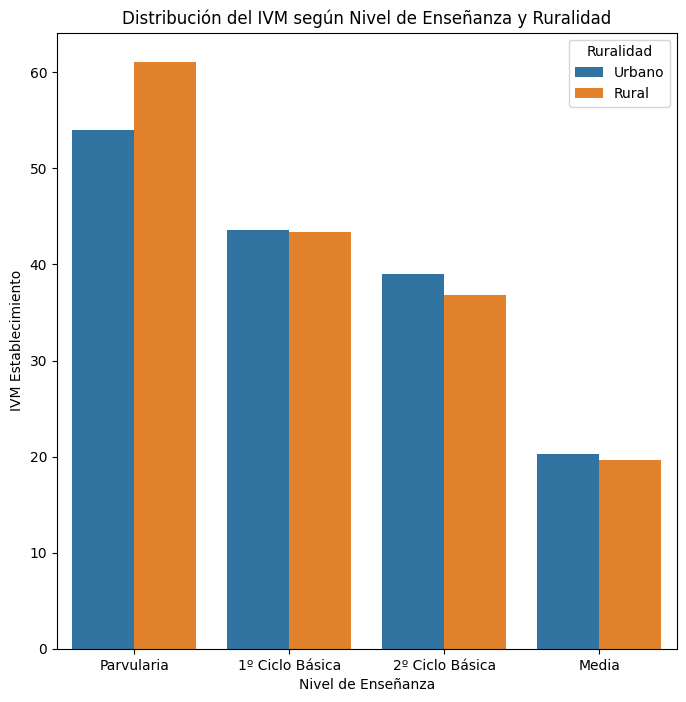

In [52]:
#4. Graficamos la distribución del IVM según nivel de enseñanza y ruralidad.
plt.figure(figsize = (8, 8))
sns.barplot(x = "Nivel", y = "IVM Establecimiento", hue = "DS_RURALIDAD", data = df_completo, errorbar = None)
plt.title("Distribución del IVM según Nivel de Enseñanza y Ruralidad")
plt.ylabel("IVM Establecimiento")
plt.xlabel("Nivel de Enseñanza")
plt.legend(title = "Ruralidad")
plt.show()

Como se puede evidenciar en el gráfico, notamos que todos los niveles de enseñanza, a excepción de parvularia, presentan un IVM mayor en establecimientos ubicados en zonas rurales.

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

In [53]:
#1. Análogamente, agrupamos por nivel de enseñanza y tipo de dependencia, calculando el IVM promedio.
distribucion_dependencia = df_completo.groupby(["Nivel", "DS_TIPO_DEPENDENCIA"])['IVM Establecimiento'].mean().unstack()
print(distribucion_dependencia)

DS_TIPO_DEPENDENCIA  Administración Delegada (C. P. 3166)  \
Nivel                                                       
1º Ciclo Básica                                 40.222215   
2º Ciclo Básica                                 40.522709   
Media                                           23.869148   
Parvularia                                            NaN   

DS_TIPO_DEPENDENCIA  Corporación Municipal  Municipal DAEM  \
Nivel                                                        
1º Ciclo Básica                  45.013497       43.656486   
2º Ciclo Básica                  39.868568       37.870933   
Media                            23.679409       20.901203   
Parvularia                       54.412060       59.037537   

DS_TIPO_DEPENDENCIA  Particular Subvencionado  \
Nivel                                           
1º Ciclo Básica                     42.723499   
2º Ciclo Básica                     38.498390   
Media                               19.159692   
Parvularia     

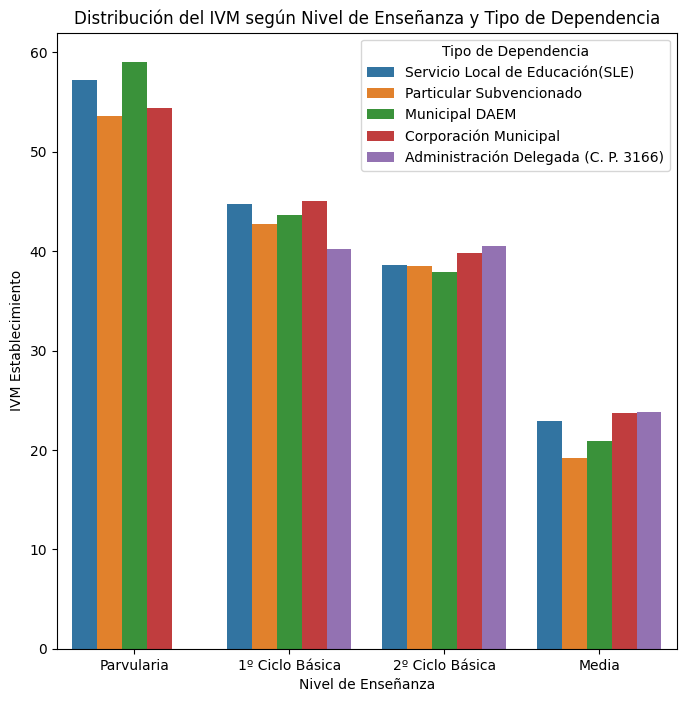

In [54]:
#2. Graficamos la distribución del IVM según nivel de enseñanza y tipo de dependencia.
plt.figure(figsize = (8, 8))
sns.barplot(x = "Nivel", y = "IVM Establecimiento", hue = "DS_TIPO_DEPENDENCIA", data = df_completo, errorbar = None)
plt.title("Distribución del IVM según Nivel de Enseñanza y Tipo de Dependencia")
plt.ylabel("IVM Establecimiento")
plt.xlabel("Nivel de Enseñanza")
plt.legend(title = "Tipo de Dependencia")
plt.show()

A través de este gráfico se hace evidente que el nivel de enseñanza con mayor IVM es el de parvularia. Se podría explicar esta distribución si tomamos en cuenta que el nivel de parvularia es el que más variables considera al momento de calcular el IVM de cada estudiante, siendo un total de 76 variables de 6 dimensiones distintas (Familia, Contexto Socieconómico Comunal, Estimulación y Apoyo, Salud, Contexto Socioeconómico Familiar y Protección y Reparación de Derechos).

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

Respuesta y comentarios:

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [ ]:
#1. Definimos las columnas clave para agrupar.
columnas = ["ID_COMUNA_ESTABLE", "DS_COMUNA_ESTABLE", "ID_REGION_ESTABLE"]

#2. Calculamos el IVM promedio para cada nivel, agrupando por comuna.
ivm_parvularia = df_parvularia.groupby(columnas)[["IVM Establecimiento"]].mean().rename(columns = {"IVM Establecimiento": "IVM Promedio Parvularia"})

ivm_ciclo_1 = df_ciclo_basica_1.groupby(columnas)[["IVM Establecimiento"]].mean().rename(columns = {"IVM Establecimiento": "IVM Promedio 1º Ciclo Básico"})

ivm_ciclo_2 = df_ciclo_basica_2.groupby(columnas)[["IVM Establecimiento"]].mean().rename(columns = {"IVM Establecimiento": "IVM Promedio 2º Ciclo Básico"})

ivm_media = df_media.groupby(columnas)[["IVM Establecimiento"]].mean().rename(columns = {"IVM Establecimiento": "IVM Promedio Media"})

#3. Combinamos los DataFrames agregados.
dfs = [ivm_parvularia, ivm_ciclo_1, ivm_ciclo_2, ivm_media]
ivm_comunal = pd.concat(dfs, axis = 1)

#4. Convertir el índice (ID_COMUNA, DS_COMUNA, ID_REGION) de nuevo a columnas
ivm_comunal = ivm_comunal.reset_index()

#5. Renombramos las columnas claves
ivm_comunal = ivm_comunal.rename(columns = {"ID_COMUNA_ESTABLE": "Comuna (ID)"})
ivm_comunal = ivm_comunal.rename(columns = {"DS_COMUNA_ESTABLE": "Comuna (Nombre)"})
ivm_comunal = ivm_comunal.rename(columns = {"ID_REGION_ESTABLE": "Región (ID)"})

ivm_comunal.head()

,Comuna (ID),Comuna (Nombre),Región (ID),IVM Promedio Parvularia,IVM Promedio 1º Ciclo Básico,IVM Promedio 2º Ciclo Básico,IVM Promedio Media
0,1101,Iquique,1,50.882970,45.131982,39.182182,22.109517
1,1107,Alto Hospicio,1,55.419776,46.599904,41.289463,24.250219
2,1401,Pozo Almonte,1,59.804991,44.159905,35.386361,22.676408
3,1402,Camiña,1,68.812360,46.127984,34.998365,17.966318
4,1403,Colchane,1,71.742419,56.888644,32.721880,27.648785


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [ ]:
# 1. Definimos las columnas clave para el análisis.
columnas = ["ID_RBD", "ID_COMUNA_ESTABLE", "DS_RURALIDAD"]

#2. Combinamos los cuatro DataFrames.
dfs = [df_parvularia[columnas], df_ciclo_basica_1[columnas], df_ciclo_basica_2[columnas], df_media[columnas]]
df_general = pd.concat(dfs, ignore_index = True)

#3. Eliminamos los duplicados del DataFrame general.
df_estab = df_general.drop_duplicates(subset=["ID_RBD"])

#4. Agrupamos y contamos establecimientos por comuna y ruralidad
estab_comunal = pd.crosstab(df_estab["ID_COMUNA_ESTABLE"], df_estab["DS_RURALIDAD"])

#5. Creamos el DataFrame final
df_comuna_ruralidad = pd.DataFrame()
df_comuna_ruralidad["Cantidad de establecimientos rurales"] = estab_comunal["Rural"]
df_comuna_ruralidad["Cantidad de establecimientos urbanos"] = estab_comunal["Urbano"]
df_comuna_ruralidad["Cantidad total de establecimientos"] = df_comuna_ruralidad["Cantidad de establecimientos rurales"] + df_comuna_ruralidad["Cantidad de establecimientos urbanos"]
df_comuna_ruralidad["Porcentaje de establecimientos rurales"] = (df_comuna_ruralidad["Cantidad de establecimientos rurales"] / df_comuna_ruralidad["Cantidad total de establecimientos"]) * 100

#6. Convertimos el índice de nuevo a columna
df_comuna_ruralidad = df_comuna_ruralidad.reset_index()
df_comuna_ruralidad = df_comuna_ruralidad.rename(columns={"ID_COMUNA_ESTABLE": "Comuna (ID)"})

df_comuna_ruralidad.head()

,Comuna (ID),Cantidad de establecimientos rurales,Cantidad de establecimientos urbanos,Cantidad total de establecimientos,Porcentaje de establecimientos rurales
0,1101,3,81,84,3.571429
1,1107,3,41,44,6.818182
2,1401,12,0,12,100.000000
3,1402,10,0,10,100.000000
4,1403,4,0,4,100.000000


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [ ]:
#1. Combinamos la base de IVM con la de ruralidad.
agg_comunal_temp = pd.merge(ivm_comunal, df_comuna_ruralidad, on = "Comuna (ID)", how = "outer")

#2. Combinamos el resultado anterior con la información geográfica.
agg_comunal_geo = pd.merge(agg_comunal_temp, gdf_comunas[["cod_comuna", "geometry"]], left_on = "Comuna (ID)", right_on = "cod_comuna", how = "left")

#3. Limpiamos columnas duplicadas
agg_comunal_final = agg_comunal_geo.drop(columns = ["cod_comuna"])

#4. Convertimos el DataFrame final a un GeoDataFrame
agg_comunal = gpd.GeoDataFrame(agg_comunal_final, geometry = "geometry")

agg_comunal.head()

,Comuna (ID),Comuna (Nombre),Región (ID),IVM Promedio Parvularia,IVM Promedio 1º Ciclo Básico,IVM Promedio 2º Ciclo Básico,IVM Promedio Media,Cantidad de establecimientos rurales,Cantidad de establecimientos urbanos,Cantidad total de establecimientos,Porcentaje de establecimientos rurales,geometry
0,1101,Iquique,1,50.882970,45.131982,39.182182,22.109517,3,81,84,3.571429,"MULTIPOLYGON (((-70.16034 -20.2107, -70.16031 ..."
1,1107,Alto Hospicio,1,55.419776,46.599904,41.289463,24.250219,3,41,44,6.818182,"POLYGON ((-69.89186 -20.06942, -69.89629 -20.1..."
2,1401,Pozo Almonte,1,59.804991,44.159905,35.386361,22.676408,12,0,12,100.000000,"POLYGON ((-68.99185 -19.92108, -68.98991 -19.9..."
3,1402,Camiña,1,68.812360,46.127984,34.998365,17.966318,10,0,10,100.000000,"POLYGON ((-69.31618 -19.13105, -69.31681 -19.1..."
4,1403,Colchane,1,71.742419,56.888644,32.721880,27.648785,4,0,4,100.000000,"POLYGON ((-69.00747 -18.95272, -69.0074 -18.95..."


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

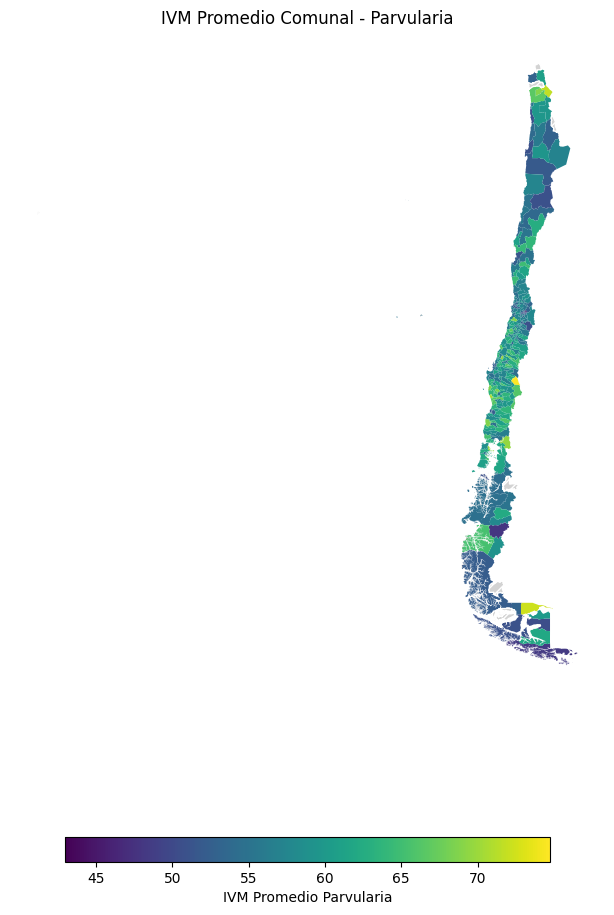

In [80]:
# Mapa Parvularia:

#1. Creamos la figura y el eje para el mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

#2. Definimos el estilo para comunas sin datos
missing_kwds = {"color": "lightgrey", "edgecolor": "white", "hatch": "///"}

#3. Opciones para la leyenda (barra de color)
legend_kwds = {"label": "IVM Promedio Parvularia", "orientation": "horizontal", "shrink": 0.5}

#4. Graficamos directamente desde 'agg_comunal'
agg_comunal.plot(
    column = "IVM Promedio Parvularia",
    ax = ax, 
    legend = True, 
    cmap = "viridis",
    missing_kwds = missing_kwds,
    legend_kwds = legend_kwds)

# 5. Ajustes finales
ax.set_title("IVM Promedio Comunal - Parvularia")
ax.set_axis_off()
plt.tight_layout()
plt.show()

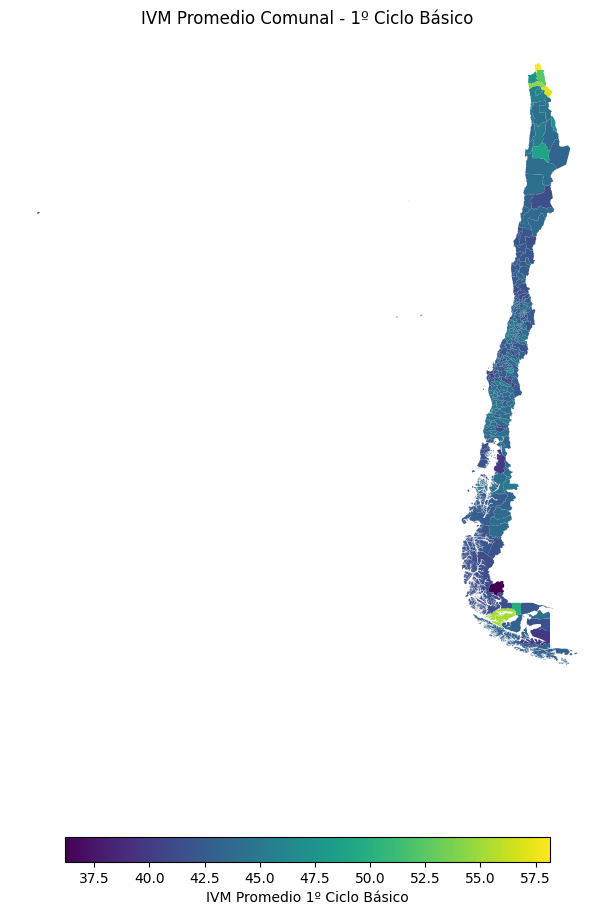

In [82]:
# Mapa Básica 1

#1. Creamos la figura y el eje para el mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

#2. Definimos el estilo para comunas sin datos
missing_kwds = {"color": "lightgrey", "edgecolor": "white", "hatch": "///"}

#3. Opciones para la leyenda (barra de color)
legend_kwds = {"label": "IVM Promedio 1º Ciclo Básico", "orientation": "horizontal", "shrink": 0.5}

#4. Graficamos directamente desde 'agg_comunal'
agg_comunal.plot(
    column = "IVM Promedio 1º Ciclo Básico",
    ax = ax, 
    legend = True, 
    cmap = "viridis",
    missing_kwds = missing_kwds,
    legend_kwds = legend_kwds)

# 5. Ajustes finales
ax.set_title("IVM Promedio Comunal - 1º Ciclo Básico")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Comentarios y análisis:

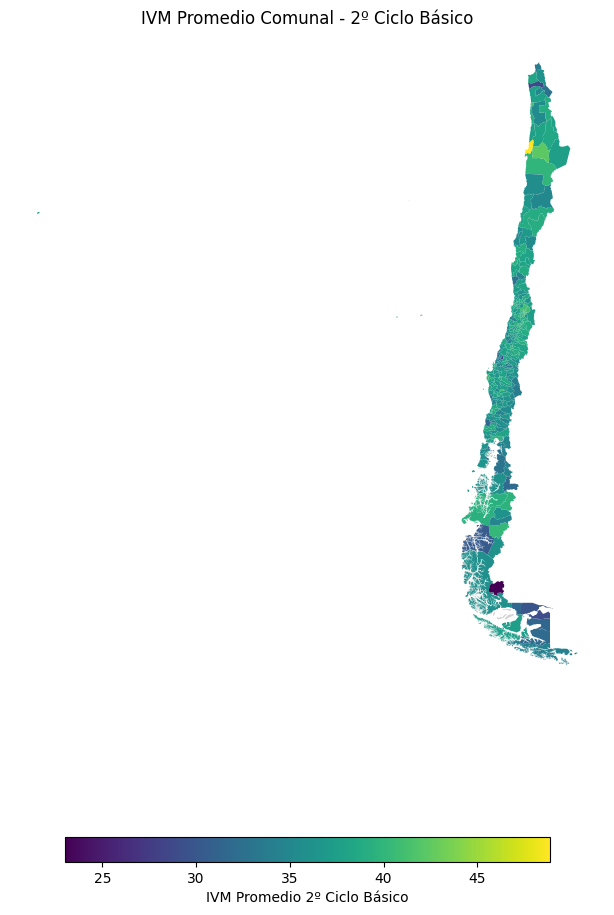

In [83]:
# Mapa Básica 2

#1. Creamos la figura y el eje para el mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

#2. Definimos el estilo para comunas sin datos
missing_kwds = {"color": "lightgrey", "edgecolor": "white", "hatch": "///"}

#3. Opciones para la leyenda (barra de color)
legend_kwds = {"label": "IVM Promedio 2º Ciclo Básico", "orientation": "horizontal", "shrink": 0.5}

#4. Graficamos directamente desde 'agg_comunal'
agg_comunal.plot(
    column = "IVM Promedio 2º Ciclo Básico",
    ax = ax, 
    legend = True, 
    cmap = "viridis",
    missing_kwds = missing_kwds,
    legend_kwds = legend_kwds)

# 5. Ajustes finales
ax.set_title("IVM Promedio Comunal - 2º Ciclo Básico")
ax.set_axis_off()
plt.tight_layout()
plt.show()

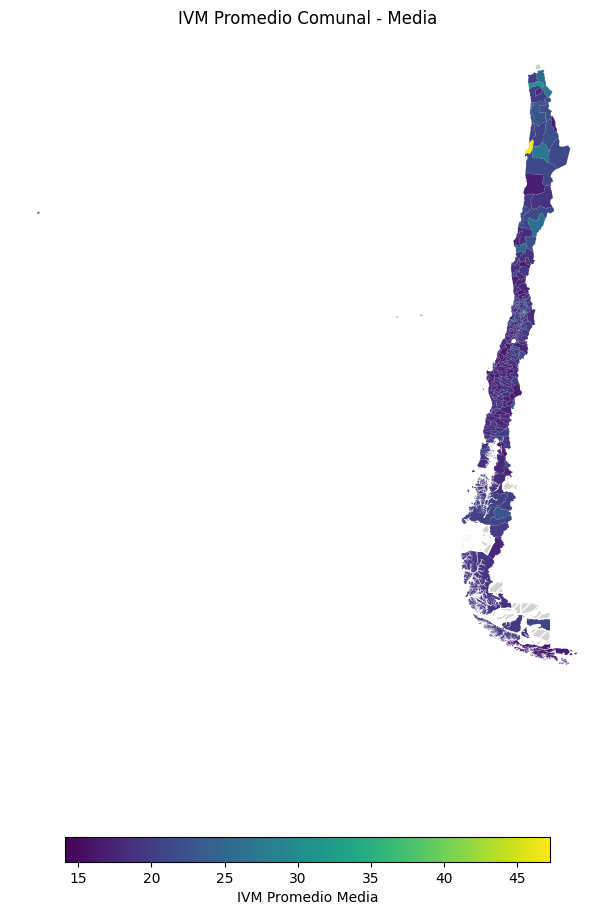

In [84]:
# Mapa Media

#1. Creamos la figura y el eje para el mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

#2. Definimos el estilo para comunas sin datos
missing_kwds = {"color": "lightgrey", "edgecolor": "white", "hatch": "///"}

#3. Opciones para la leyenda (barra de color)
legend_kwds = {"label": "IVM Promedio Media", "orientation": "horizontal", "shrink": 0.5}

#4. Graficamos directamente desde 'agg_comunal'
agg_comunal.plot(
    column = "IVM Promedio Media",
    ax = ax, 
    legend = True, 
    cmap = "viridis",
    missing_kwds = missing_kwds,
    legend_kwds = legend_kwds)

# 5. Ajustes finales
ax.set_title("IVM Promedio Comunal - Media")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

In [ ]:
# respuestas

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:**